# The Monty Hall Problem

This problem has puzzled many people over the years. Let's investigate it by simulation.

The setting is a game show with three closed doors. Behind one door is a car and behind each of the other two doors is a goat. The contestant chooses a door, Monty opens a different door that reveals a goat, and the contestant must decide whether to stay with the original choice or switch to the remaining unopened door.

Should the contestant stay or switch?

In [1]:
import pandas as pd
path_data = "../../../assets/data/"
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

## The Solution

Assume the contestant is equally likely to pick any of the three doors.

- The chance that the originally chosen door hides the car is 1/3.
- The car must be behind either the originally chosen door or the remaining unopened door.
- Therefore the remaining unopened door has probability 2/3 of hiding the car.
- Therefore the contestant should switch.

If that argument is not convincing, we can use simulation.

## Simulation

**Step 1: What to Simulate**

For each play we will simulate:
- the contestant's original choice
- the goat revealed by Monty
- the item behind the remaining unopened door

**Step 2: Simulating One Play**

We begin by creating an array containing the two goats.

In [2]:
goats = np.array(['first goat', 'second goat'])

To help with the simulation, the function `other_goat` returns the goat that was not selected.

In [3]:
def other_goat(x):
    if x == "first goat":
        return "second goat"
    elif x == "second goat":
        return "first goat"

In [4]:
other_goat('first goat'), other_goat('second goat'), other_goat('watermelon')

('second goat', 'first goat', None)

The input `watermelon` is not one of the goat names, so the function returns no value.

**The options:** The array `hidden_behind_doors` contains the three items that could be behind the doors.

In [5]:
hidden_behind_doors = np.append(goats, 'car')
hidden_behind_doors

array(['first goat', 'second goat', 'car'], dtype='<U11')

We can now define a function that simulates one complete game. The function returns:

- the contestant's original choice
- the item revealed by Monty
- the item behind the remaining unopened door

In [6]:
def monty_hall_game():
    """Return [guess, revealed, remaining] for one game"""

    contestant_guess = np.random.choice(hidden_behind_doors)

    if contestant_guess == "first goat":
        return [contestant_guess, "second goat", "car"]

    if contestant_guess == "second goat":
        return [contestant_guess, "first goat", "car"]

    if contestant_guess == "car":
        revealed = np.random.choice(goats)
        return [contestant_guess, revealed, other_goat(revealed)]

Let's play one game.

In [7]:
monty_hall_game()

[np.str_('car'), np.str_('first goat'), 'second goat']

**Step 3: Number of Repetitions**

We will simulate 10,000 games.

**Step 4: Simulating Multiple Repetitions**

Unlike previous examples, each simulation produces three values. We will store the results in a pandas DataFrame.

In [8]:
games = []

for i in np.arange(10000):
    games.append(monty_hall_game())

games = pd.DataFrame(games, columns=["Guess", "Revealed", "Remaining"])

The simulation is complete.

In [9]:
games.head(3)

,Guess,Revealed,Remaining
0,second goat,first goat,car
1,car,first goat,second goat
2,car,first goat,second goat


## Visualization

To see whether the contestant should stay or switch, let's compare how often the car appears in the original choice and in the remaining door.

The original choices are approximately evenly distributed among the three possibilities.

In [10]:
original_choice = games.groupby("Guess").size().reset_index(name="count")
original_choice

,Guess,count
0,car,3310
1,first goat,3334
2,second goat,3356


How often is the car behind the remaining unopened door?

In [11]:
remaining_door = games.groupby("Remaining").size().reset_index(name="count")
remaining_door

,Remaining,count
0,car,6690
1,first goat,1672
2,second goat,1638


The simulation shows that the car is behind the remaining door about two-thirds of the time.

In [12]:
combined = pd.merge(original_choice, remaining_door, left_on="Guess", right_on="Remaining")
combined = combined[["Guess", "count_x", "count_y"]]
combined.columns = ["Item", "Original Door", "Remaining Door"]
combined

,Item,Original Door,Remaining Door
0,car,3310,6690
1,first goat,3334,1672
2,second goat,3356,1638


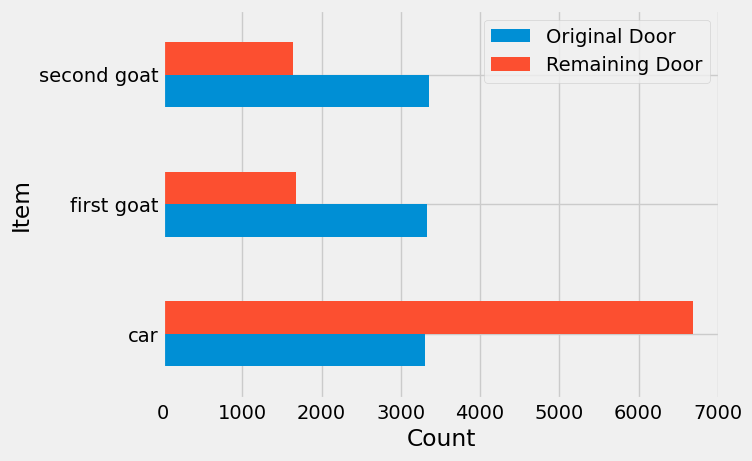

In [13]:
plot_df = combined.set_index("Item")
plot_df.plot.barh()
plt.xlabel("Count")
plt.show()

The bars show that the original choice is equally likely to be any of the three items, while the car appears behind the remaining unopened door about twice as often. The simulation confirms that a contestant is about twice as likely to win the car by switching.